# 🎙️ Voice-to-Reddit Post Generator
### Pipeline: Voice → Whisper STT → Llama 3 → SDXL Turbo → Reddit Post

This notebook takes a voice recording as input and produces a complete Reddit post:
- **Title** — catchy, platform-appropriate
- **Body text** — fleshed-out post content
- **Image** — AI-generated from the content context

> ⚠️ Designed for **Google Colab T4 GPU**. Each model is loaded, used, and unloaded sequentially to avoid OOM errors.

In [1]:
# ==========================================
# CELL 1: INSTALLATIONS & DEPENDENCIES
# ==========================================
!pip install -q "datasets<3.0.0"
!pip install -q transformers diffusers accelerate bitsandbytes openai-whisper sentencepiece scipy datasets soundfile

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Pipeline ready. Compute device: {device}")
if device == "cpu":
    print("⚠️  Warning: Running on CPU will be very slow. Switch to a T4 GPU runtime in Colab.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 11.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 14.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.1 MB/s eta 0:00:00
✅ Pipeline ready. Compute device: cuda


In [2]:
# ==========================================
# CELL 2: CORE IMPORTS
# ==========================================
import re
import gc
import json
import torch
import whisper
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from diffusers import AutoPipelineForText2Image
from IPython.display import display

print("✅ All imports successful.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


✅ All imports successful.


In [3]:
# ==========================================
# CELL 3: PIPELINE FUNCTIONS
# ==========================================

def flush_memory():
    """Aggressively release GPU memory after each stage."""
    gc.collect()
    torch.cuda.empty_cache()


# ------------------------------------------
# STAGE 1 — Speech-to-Text (Whisper Base)
# ------------------------------------------
def transcribe_voice(audio_path: str) -> str:
    """
    Transcribe a WAV audio file to text using OpenAI Whisper (base model).

    Args:
        audio_path: Path to the .wav audio file.

    Returns:
        Transcribed text string.
    """
    print("🎙️  [Stage 1] Loading Whisper (Base)...")
    model = whisper.load_model("base").to(device)

    result = model.transcribe(audio_path)
    transcript = result["text"].strip()

    del model
    flush_memory()

    print("✅ [Stage 1] Transcription complete.")
    return transcript


# ------------------------------------------
# STAGE 2 — Reddit Content Generation (Llama 3 8B, 4-bit)
# ------------------------------------------
def generate_reddit_content(transcript: str) -> dict:
    """
    Use Llama 3 (8B, 4-bit quantized) to convert a transcript into
    a structured Reddit post with title, body, and an image prompt.

    Args:
        transcript: The raw transcribed text from Stage 1.

    Returns:
        A dict with keys: 'reddit_title', 'reddit_body', 'image_prompt'.
    """
    print("🧠 [Stage 2] Loading Llama-3 (8B, 4-bit)...")
    model_id = "unsloth/llama-3-8b-Instruct-bnb-4bit"

    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=quantization_config,
        device_map="auto"
    )

    # Prompt instructs the model to produce a Reddit-style post
    prompt = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert Reddit content creator. Convert the transcript into a compelling Reddit post.
Output ONLY a valid JSON object. Do not include any preamble, explanation, or markdown fences.
The JSON must follow this exact format:
{{
  "reddit_title": "A concise, attention-grabbing post title (max 300 characters, no clickbait).",
  "reddit_body": "A well-structured post body with 2-4 paragraphs. Use Reddit markdown (bold with **text**, bullet points with -, paragraph breaks with two newlines). Be engaging and conversational.",
  "image_prompt": "A detailed, photorealistic or illustrative text-to-image prompt for Stable Diffusion that visually represents the post topic."
}}
<|eot_id|><|start_header_id|>user<|end_header_id|>
Transcript: \"{transcript}\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>"""

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=768,   # Reddit body needs more tokens than a tweet
        temperature=0.7,
        do_sample=True
    )
    response = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )

    del tokenizer, model, inputs, outputs
    flush_memory()

    # Failsafe: if model forgot the closing brace, add it
    if "{" in response and response.count("}") < response.count("{"):
        response += "\n}"

    try:
        json_match = re.search(r'\{.*\}', response, re.DOTALL)
        if json_match:
            content = json.loads(json_match.group(0))
        else:
            raise ValueError("No JSON object found in model output.")
    except Exception as e:
        print(f"⚠️  JSON parsing failed: {e}")
        print(f"Raw model output:\n{response}")
        content = {
            "reddit_title": "Something interesting happened today",
            "reddit_body": "I wanted to share this experience but the AI had trouble formatting it. Here's the raw idea: " + transcript,
            "image_prompt": "Abstract colorful digital art background"
        }

    print("✅ [Stage 2] Reddit content generated.")
    return content


# ------------------------------------------
# STAGE 3 — Image Generation (SDXL Turbo)
# ------------------------------------------
def generate_image(prompt: str):
    """
    Generate an image using SDXL Turbo from a text prompt.

    Args:
        prompt: The image generation prompt from Stage 2.

    Returns:
        A PIL Image object.
    """
    print("🎨 [Stage 3] Loading SDXL Turbo...")
    pipe = AutoPipelineForText2Image.from_pretrained(
        "stabilityai/sdxl-turbo",
        torch_dtype=torch.float16,
        variant="fp16"
    ).to(device)

    # SDXL Turbo is a distilled model — 3 steps, no CFG (guidance_scale=0.0)
    image = pipe(
        prompt=prompt,
        num_inference_steps=3,
        guidance_scale=0.0
    ).images[0]

    del pipe
    flush_memory()

    print("✅ [Stage 3] Image generated.")
    return image


print("✅ All pipeline functions defined.")

✅ All pipeline functions defined.


📥 Downloading test audio dataset (google/fleurs - US English)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

...

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


✅ [Stage 3] Image generated.
----------------------------------------------------------------------
🎉 FINAL REDDIT POST PREVIEW
----------------------------------------------------------------------


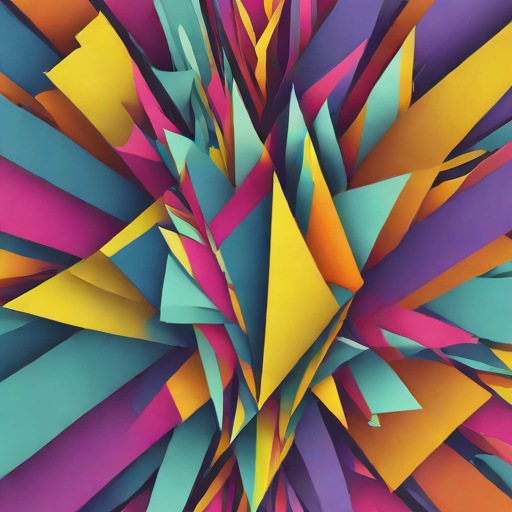



🚀 SAMPLE 2 / 3
🎙️  [Stage 1] Loading Whisper (Base)...
✅ [Stage 1] Transcription complete.

📝 Transcript:
Although some scholars speculate that since the civilization also existed in the basins of the now dried up, Sarasvati River, it should be aptly be called the Endus Sarasvati civilization, while some called the Harapana civilization after the Harapah, the first of sites to be excavated in the 1920s.

🧠 [Stage 2] Loading Llama-3 (8B, 4-bit)...


/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:246: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

⚠️  JSON parsing failed: Invalid control character at: line 3 column 95 (char 213)
Raw model output:


{
  "reddit_title": "Uncovering the Ancient Endus Sarasvati or Harapana Civilization: A Forgotten Chapter in History",
  "reddit_body": "**Unraveling the Mysteries of the Endus Sarasvati or Harapana Civilization**

For centuries, the ruins of this ancient civilization have fascinated historians and archaeologists alike. The debate continues to rage on about its true name - should it be called the Endus Sarasvati civilization, due to its presence in the basins of the now dried-up Sarasvati River, or the Harapana civilization, named after the first excavated site in the 1920s? **Let's dive into the history and uncover the secrets of this forgotten chapter in human civilization.**

- The civilization is believed to have thrived in the Indus Valley region, with evidence of sophisticated urban planning, architecture, and irrigation systems.
- The Harapah site, discovered in the 1920s, prov

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


...

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


✅ [Stage 3] Image generated.
----------------------------------------------------------------------
🎉 FINAL REDDIT POST PREVIEW
----------------------------------------------------------------------


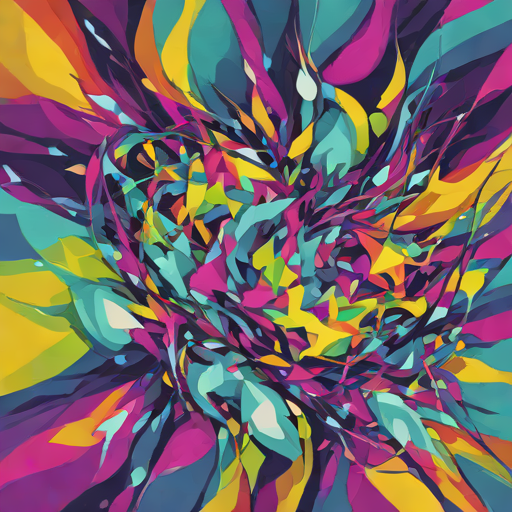



🚀 SAMPLE 3 / 3
🎙️  [Stage 1] Loading Whisper (Base)...
✅ [Stage 1] Transcription complete.

📝 Transcript:
After the match, King of Clay said, I am just excited about being back in the final rounds of the most important events. I'm here to try to win this.

🧠 [Stage 2] Loading Llama-3 (8B, 4-bit)...


/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:246: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

⚠️  JSON parsing failed: Expecting ',' delimiter: line 3 column 325 (char 408)
Raw model output:
assistant{
  "reddit_title": "Rafael Nadal's Post-Match Quote: Unwavering Focus on Victory",
  "reddit_body": "The King of Clay, Rafael Nadal, has done it again! Just hours ago, he took to the court and dominated his opponent in a thrilling match. In a post-match interview, Nadal expressed his excitement about being back in the final rounds of the most important events. **When asked about his goals**, he said, **"I'm here to try to win this."** It's no secret that Nadal is a force to be reckoned with on the court. His determination and focus are traits that have earned him a reputation as one of the greatest tennis players of all time. What do you think about Nadal's chances of taking home the title? Do you have a favorite tennis player? Share your thoughts in the comments below!",
  "image_prompt": "A dramatic illustration of Rafael Nadal standing on the tennis court, racket in hand, with 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


...

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


✅ [Stage 3] Image generated.
----------------------------------------------------------------------
🎉 FINAL REDDIT POST PREVIEW
----------------------------------------------------------------------


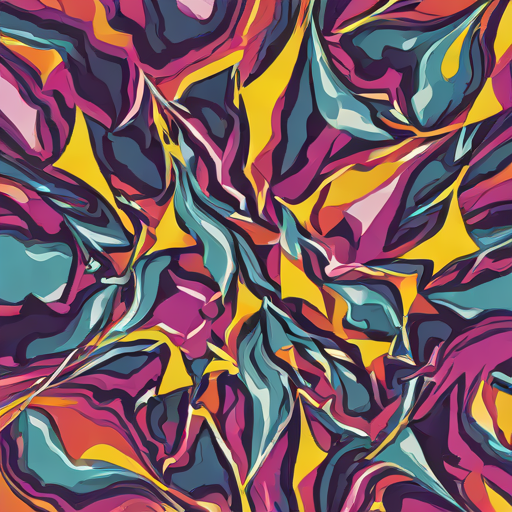

In [4]:
# ==========================================
# CELL 4: DATASET LOADING & TEST RUN
# Runs the full pipeline on 3 random audio samples
# from the Google FLEURS English dataset.
# ==========================================
import soundfile as sf
from datasets import load_dataset
from IPython.display import display, HTML

print("📥 Downloading test audio dataset (google/fleurs - US English)...")
dataset = load_dataset("google/fleurs", "en_us", split="train", trust_remote_code=True)
shuffled_dataset = dataset.shuffle(seed=99)
test_samples = shuffled_dataset.select(range(3))  # 3 samples to save time

print(f"✅ Loaded {len(test_samples)} audio samples for testing.\n")

for i, sample in enumerate(test_samples):
    print("="*70)
    print(f"🚀 SAMPLE {i+1} / {len(test_samples)}")
    print("="*70)

    # --- Prepare audio file ---
    audio_array = sample["audio"]["array"]
    sample_rate = sample["audio"]["sampling_rate"]
    audio_path = f"test_audio_{i}.wav"
    sf.write(audio_path, audio_array, sample_rate)

    # --- Stage 1: Speech-to-Text ---
    transcript = transcribe_voice(audio_path)
    print(f"\n📝 Transcript:\n{transcript}\n")

    # --- Stage 2: Reddit Content Generation ---
    content = generate_reddit_content(transcript)
    reddit_title  = content.get("reddit_title",  "Untitled Post")
    reddit_body   = content.get("reddit_body",   "(no body generated)")
    image_prompt  = content.get("image_prompt",  "Abstract colorful background")

    print(f"📌 Reddit Title:\n{reddit_title}\n")
    print(f"📄 Reddit Body:\n{reddit_body}\n")
    print(f"🖼️  Image Prompt:\n{image_prompt}\n")

    # --- Stage 3: Image Generation ---
    post_image = generate_image(image_prompt)

    # --- Display Final Reddit Post Preview ---
    print("-"*70)
    print("🎉 FINAL REDDIT POST PREVIEW")
    print("-"*70)
    display(HTML(f"<h3>r/general &nbsp;·&nbsp; Posted by u/VoiceAI_Bot</h3><h2>{reddit_title}</h2>"))
    display(HTML(f"<p style='font-size:15px; line-height:1.7'>{reddit_body.replace(chr(10), '<br>')}</p>"))
    display(post_image)
    print("\n")

In [5]:
# ==========================================
# CELL 5: FASTAPI APP DEFINITION
# Writes app.py to disk for deployment.
# Run this cell, then Cell 6 to launch the server.
# ==========================================
%%writefile app.py
import os
import gc
import json
import re
import uuid
import torch
import whisper
import soundfile as sf
from fastapi import FastAPI, UploadFile, File
from fastapi.responses import HTMLResponse, FileResponse
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from diffusers import AutoPipelineForText2Image

app = FastAPI(title="Voice-to-Reddit API")
os.makedirs("output_images", exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ── Helpers ────────────────────────────────────────────────────────────────
def flush_memory():
    gc.collect()
    torch.cuda.empty_cache()

# ── Stage 1: Speech-to-Text ────────────────────────────────────────────────
def transcribe_voice(audio_path: str) -> str:
    model = whisper.load_model("base").to(device)
    result = model.transcribe(audio_path)
    transcript = result["text"].strip()
    del model
    flush_memory()
    return transcript

# ── Stage 2: Reddit Content Generation ────────────────────────────────────
def generate_reddit_content(transcript: str) -> dict:
    model_id = "unsloth/llama-3-8b-Instruct-bnb-4bit"
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id, quantization_config=quantization_config, device_map="auto"
    )

    prompt = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert Reddit content creator. Convert the transcript into a compelling Reddit post.
Output ONLY a valid JSON object. Do not include any preamble, explanation, or markdown fences.
The JSON must follow this exact format:
{{
  "reddit_title": "A concise, attention-grabbing post title (max 300 characters, no clickbait).",
  "reddit_body": "A well-structured post body with 2-4 paragraphs. Use Reddit markdown. Be engaging and conversational.",
  "image_prompt": "A detailed text-to-image prompt for Stable Diffusion that visually represents the post topic."
}}
<|eot_id|><|start_header_id|>user<|end_header_id|>
Transcript: \"{transcript}\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>"""

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    outputs = model.generate(**inputs, max_new_tokens=768, temperature=0.7, do_sample=True)
    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)

    del tokenizer, model, inputs, outputs
    flush_memory()

    if "{" in response and response.count("}") < response.count("{"):
        response += "\n}"

    try:
        json_match = re.search(r'\{.*\}', response, re.DOTALL)
        if json_match:
            content = json.loads(json_match.group(0))
        else:
            raise ValueError("No JSON object in model output.")
    except Exception:
        content = {
            "reddit_title": "Something interesting happened",
            "reddit_body": transcript,
            "image_prompt": "Abstract colorful digital art background"
        }
    return content

# ── Stage 3: Image Generation ──────────────────────────────────────────────
def generate_image(prompt: str):
    pipe = AutoPipelineForText2Image.from_pretrained(
        "stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16"
    ).to(device)
    image = pipe(prompt=prompt, num_inference_steps=3, guidance_scale=0.0).images[0]
    del pipe
    flush_memory()
    return image

# ── Frontend ───────────────────────────────────────────────────────────────
@app.get("/", response_class=HTMLResponse)
async def get_index():
    html_content = """
    <!DOCTYPE html>
    <html lang="en">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <title>Voice-to-Reddit AI</title>
        <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;600;800&display=swap" rel="stylesheet">
        <style>
            :root {
                --bg: #dae0e6;
                --card-bg: #ffffff;
                --header-bg: #ff4500;
                --text: #1c1c1c;
                --muted: #878a8c;
                --accent: #ff4500;
                --border: #edeff1;
            }
            * { box-sizing: border-box; margin: 0; padding: 0; }
            body {
                font-family: 'Inter', -apple-system, sans-serif;
                background: var(--bg);
                color: var(--text);
                min-height: 100vh;
            }
            header {
                background: var(--header-bg);
                padding: 12px 24px;
                display: flex;
                align-items: center;
                gap: 10px;
            }
            header h1 { color: #fff; font-size: 20px; font-weight: 800; }

            .layout {
                max-width: 740px;
                margin: 24px auto;
                padding: 0 16px;
                display: flex;
                flex-direction: column;
                gap: 16px;
            }

            .card {
                background: var(--card-bg);
                border: 1px solid var(--border);
                border-radius: 4px;
                padding: 24px;
            }
            .card h2 { font-size: 16px; font-weight: 700; margin-bottom: 6px; }
            .card p.sub { font-size: 13px; color: var(--muted); margin-bottom: 20px; }

            button {
                background: var(--accent);
                color: white;
                border: none;
                padding: 10px 24px;
                font-size: 14px;
                font-weight: 700;
                border-radius: 20px;
                cursor: pointer;
                display: inline-flex;
                align-items: center;
                gap: 8px;
                transition: opacity 0.15s;
            }
            button:hover { opacity: 0.85; }
            button.recording { background: #c00; animation: pulse 1.5s infinite; }
            @keyframes pulse {
                0%, 100% { box-shadow: 0 0 0 0 rgba(200,0,0,0.4); }
                50% { box-shadow: 0 0 0 12px rgba(200,0,0,0); }
            }

            .spinner-wrap { display: none; align-items: center; gap: 12px; margin-top: 16px; color: var(--muted); font-size: 13px; }
            .spinner { width: 20px; height: 20px; border: 3px solid var(--border); border-top-color: var(--accent); border-radius: 50%; animation: spin 0.8s linear infinite; }
            @keyframes spin { to { transform: rotate(360deg); } }

            /* Reddit post preview */
            .post-card { display: none; }
            .post-meta { font-size: 12px; color: var(--muted); margin-bottom: 8px; }
            .post-title { font-size: 18px; font-weight: 700; line-height: 1.4; margin-bottom: 12px; }
            .post-body { font-size: 14px; line-height: 1.7; white-space: pre-wrap; margin-bottom: 16px; }
            .post-image { width: 100%; border-radius: 4px; border: 1px solid var(--border); }
            .post-actions { display: flex; gap: 16px; margin-top: 14px; }
            .action-btn { font-size: 12px; font-weight: 700; color: var(--muted); background: none; border: none; padding: 6px 8px; border-radius: 2px; cursor: pointer; }
            .action-btn:hover { background: var(--border); opacity: 1; color: var(--text); }

            .transcript-box { font-size: 12px; color: var(--muted); background: var(--bg); padding: 10px 14px; border-radius: 4px; border-left: 3px solid var(--muted); margin-bottom: 16px; }
        </style>
    </head>
    <body>
        <header>
            <span style="font-size:24px">🤖</span>
            <h1>Voice-to-Reddit AI</h1>
        </header>

        <div class="layout">
            <!-- Recording card -->
            <div class="card">
                <h2>Create a Reddit Post from Your Voice</h2>
                <p class="sub">Record yourself speaking, and the AI will generate a full Reddit post — title, body, and image.</p>
                <button id="recordBtn" onclick="toggleRecording()">
                    <span id="btnIcon">🔴</span>
                    <span id="btnText">Start Recording</span>
                </button>
                <div class="spinner-wrap" id="loader">
                    <div class="spinner"></div>
                    <span>Transcribing → Generating post → Creating image…</span>
                </div>
            </div>

            <!-- Post preview card -->
            <div class="card post-card" id="postCard">
                <div class="transcript-box" id="transcriptBox"></div>
                <div class="post-meta">r/general &nbsp;·&nbsp; Posted by <strong>u/VoiceAI_Bot</strong> &nbsp;·&nbsp; just now</div>
                <div class="post-title" id="postTitle"></div>
                <div class="post-body" id="postBody"></div>
                <img class="post-image" id="postImage" src="" alt="AI Generated Image" />
                <div class="post-actions">
                    <button class="action-btn">⬆ Upvote</button>
                    <button class="action-btn">⬇ Downvote</button>
                    <button class="action-btn">💬 Comment</button>
                    <button class="action-btn">🔗 Share</button>
                </div>
            </div>
        </div>

        <script>
            let mediaRecorder, audioChunks = [], isRecording = false;

            async function toggleRecording() {
                const btn      = document.getElementById("recordBtn");
                const btnIcon  = document.getElementById("btnIcon");
                const btnText  = document.getElementById("btnText");
                const loader   = document.getElementById("loader");
                const postCard = document.getElementById("postCard");

                if (!isRecording) {
                    const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
                    mediaRecorder = new MediaRecorder(stream);
                    mediaRecorder.ondataavailable = e => audioChunks.push(e.data);
                    mediaRecorder.onstop = async () => {
                        const blob = new Blob(audioChunks, { type: "audio/wav" });
                        audioChunks = [];
                        const form = new FormData();
                        form.append("file", blob, "recording.wav");

                        loader.style.display = "flex";
                        postCard.style.display = "none";

                        try {
                            const res  = await fetch("/process", { method: "POST", body: form });
                            const data = await res.json();

                            loader.style.display = "none";
                            postCard.style.display = "block";

                            document.getElementById("transcriptBox").innerText = '🎙️ Heard: "' + data.transcript + '"';
                            document.getElementById("postTitle").innerText  = data.reddit_title;
                            document.getElementById("postBody").innerText   = data.reddit_body;
                            document.getElementById("postImage").src        = data.image_url;
                        } catch (e) {
                            loader.style.display = "none";
                            postCard.style.display = "block";
                            document.getElementById("postTitle").innerText = "❌ Error — check the server logs.";
                        }
                    };
                    mediaRecorder.start();
                    isRecording = true;
                    btnIcon.innerText = "⏹";
                    btnText.innerText = "Stop & Generate Post";
                    btn.classList.add("recording");
                } else {
                    mediaRecorder.stop();
                    isRecording = false;
                    btnIcon.innerText = "🔴";
                    btnText.innerText = "Start Recording";
                    btn.classList.remove("recording");
                }
            }
        </script>
    </body>
    </html>
    """
    return HTMLResponse(content=html_content)


# ── API Endpoint ───────────────────────────────────────────────────────────
@app.post("/process")
async def process_audio(file: UploadFile = File(...)):
    audio_path = f"temp_{uuid.uuid4()}.wav"
    with open(audio_path, "wb") as f:
        f.write(await file.read())

    transcript = transcribe_voice(audio_path)
    content    = generate_reddit_content(transcript)

    title        = content.get("reddit_title", "Untitled")
    body         = content.get("reddit_body",  "")
    image_prompt = content.get("image_prompt", "Abstract colorful background")

    image          = generate_image(image_prompt)
    image_filename = f"{uuid.uuid4()}.png"
    image_path     = os.path.join("output_images", image_filename)
    image.save(image_path)
    os.remove(audio_path)

    return {
        "transcript":    transcript,
        "reddit_title":  title,
        "reddit_body":   body,
        "image_url":     f"/images/{image_filename}"
    }


@app.get("/images/{filename}")
async def get_image(filename: str):
    return FileResponse(os.path.join("output_images", filename))

Writing app.py


In [7]:
# ==========================================
# CELL 6: LAUNCH SERVER & EXPOSE VIA CLOUDFLARE TUNNEL
# Run this cell last. Look for the *.trycloudflare.com URL.
# ==========================================
import subprocess
import time

print("🚀 Starting FastAPI server...")
subprocess.Popen(["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"])
time.sleep(4)

print("🌍 Installing Cloudflare Tunnel...")
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb > /dev/null 2>&1

print("="*70)
print("🔗 Opening tunnel — look for the *.trycloudflare.com link below:")
print("="*70)
!cloudflared tunnel --url http://127.0.0.1:8000

🚀 Starting FastAPI server...
🌍 Installing Cloudflare Tunnel...
🔗 Opening tunnel — look for the *.trycloudflare.com link below:
2026-04-29T19:38:44Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-04-29T19:38:44Z INF Requesting new quick Tunnel on trycloudflare.com...
failed to request quick Tunnel: Post "https://api.trycloudflare.com/tunnel": context deadline exceeded (Client.Timeout exceeded while awaiting headers)
